In [1]:
import scanpy as sc
import mudata
import muon 
from scib_metrics.benchmark import Benchmarker 


c:\Users\irc\miniconda3\envs\scib\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
c:\Users\irc\miniconda3\envs\scib\Lib\site-packages\muon\_core\preproc.py:32: FutureWarning: `__version__` is deprecated, use `importlib.metadata.version('scanpy')` instead
  if Version(scanpy.__version__) < Version("1.10"):


Load in datasets

In [2]:
# load in different datasets which have the different latent representations, which will be added into one adata object to compare using scib
# the latent representations will be put in an obsm layer in an anndata object

files = {
    # scVI
    "adata_RNA_scVI": (
        "c:/Users/irc/Desktop/Internship Bioinformatics 2025-2026/Lode/Integration_scVI/scVI_integrated_object.h5ad",
        "X_scVI",
    ),
    # Harmony
    "adata_RNA_Harmony": (
        "C:/Users/irc/Desktop/Internship Bioinformatics 2025-2026/Lode/Harmony/Harmony_AnndataR_conversion/data/Harmony_RNA_integrated_anndataR.h5ad",
        "RNA_harmony",
    ),
    "adata_protein_Harmony": (
        "C:/Users/irc/Desktop/Internship Bioinformatics 2025-2026/Lode/Harmony/Harmony_AnndataR_conversion/data/Harmony_ADT_integrated_anndataR.h5ad",
        "ADT_harmony",
    ),
    # "adata_WNN_Harmony" : (
    #     "C:/Users/irc/Desktop/Internship Bioinformatics 2025-2026/Lode/Harmony/Harmony_AnndataR_conversion/data/Harmony_WNN_anndataR.h5ad",
    #     "WNN_Harmony"
    # ),
    # Samuel Harmony integration
    # "adata_RNA_Harmony_Samuel": (
    #     "C:/Users/irc/Desktop/Internship Bioinformatics 2025-2026/Lode/Harmony/Harmony_AnndataR_conversion/data/Harmony_RNA_Samuel.h5ad",
    #     "RNA_harmony",
    # ),
}

In [4]:
for file, path in files.items():
    adata = sc.read_h5ad(path[0])
    print(f"=================={file}=================")
    print(adata)

==================adata_RNA_scVI=================
AnnData object with n_obs × n_vars = 137062 × 36048
    obs: 'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'RNA_snn_res.0.5', 'seurat_clusters', 'RNA_snn_res.0.6', 'RNA_snn_res.0.7', 'RNA_snn_res.0.8', 'RNA_snn_res.0.9', 'RNA_snn_res.1', 'RNA_snn_res.1.1', 'RNA_snn_res.1.2', 'RNA_snn_res.1.3', 'RNA_snn_res.1.4', 'RNA_snn_res.1.5', 'nCount_ADT', 'nFeature_ADT', 'sctype_classification', 'scDblFinder_class', 'scDblFinder_score', 'percent.mt', 'nCount_HTO', 'nFeature_HTO', 'MULTI_ID', 'MULTI_classification', 'barcodes', 'HTO_Results', 'DF_Results', 'HTO_GUESS', 'MULTI_ID_merge', 'LENIENT_GUESS_merge', 'Annotation_VBO', 'experiment', 'treatment', 'tech', 'ADT_snn_res.1.2', 'RNA.weight', 'ADT.weight', 'wsnn_res.1', 'celltype_new', '_scvi_batch', '_scvi_labels', 'leiden_totalVI_res1'
    var: 'vf_vst_counts.1.SeuratProject.SeuratProject.SeuratProject.SeuratProject.SeuratProject.SeuratProject.SeuratProject.SeuratProject.SeuratProject.SeuratProjec

In [5]:
# load mudata separately
mdata = mudata.read_h5mu("c:/Users/irc/Desktop/Internship Bioinformatics 2025-2026/Lode/Integration_totalVI/integrated_totalVI.h5mu")

c:\Users\irc\miniconda3\envs\scib\Lib\site-packages\mudata\_core\mudata.py:1471: FutureWarning: From 0.4 .update() will not pull obs/var columns from individual modalities by default anymore. Set mudata.set_options(pull_on_update=False) to adopt the new behaviour, which will become the default. Use new pull_obs/pull_var and push_obs/push_var methods for more flexibility.
  self._update_attr("var", axis=0, join_common=join_common)
c:\Users\irc\miniconda3\envs\scib\Lib\site-packages\mudata\_core\mudata.py:613: UserWarning: Cannot join columns with the same name because var_names are intersecting.
  self._update_attr_legacy(attr, axis, join_common, **kwargs)
c:\Users\irc\miniconda3\envs\scib\Lib\site-packages\mudata\_core\mudata.py:1322: FutureWarning: From 0.4 .update() will not pull obs/var columns from individual modalities by default anymore. Set mudata.set_options(pull_on_update=False) to adopt the new behaviour, which will become the default. Use new pull_obs/pull_var and push_obs/p

Add the latent spaces into one object. For this, we will select the scVI object as the base object

In [6]:
mdata

MuData object with n_obs × n_vars = 137062 × 40268
  obs:	'_scvi_labels'
  var:	'var.features', 'var.features.rank'
  uns:	'_scvi_manager_uuid', '_scvi_uuid'
  3 modalities
    RNA:	137062 × 36048
      obs:	'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'RNA_snn_res.0.5', 'seurat_clusters', 'RNA_snn_res.0.6', 'RNA_snn_res.0.7', 'RNA_snn_res.0.8', 'RNA_snn_res.0.9', 'RNA_snn_res.1', 'RNA_snn_res.1.1', 'RNA_snn_res.1.2', 'RNA_snn_res.1.3', 'RNA_snn_res.1.4', 'RNA_snn_res.1.5', 'nCount_ADT', 'nFeature_ADT', 'sctype_classification', 'scDblFinder_class', 'scDblFinder_score', 'percent.mt', 'nCount_HTO', 'nFeature_HTO', 'MULTI_ID', 'MULTI_classification', 'barcodes', 'HTO_Results', 'DF_Results', 'HTO_GUESS', 'MULTI_ID_merge', 'LENIENT_GUESS_merge', 'Annotation_VBO', 'experiment', 'treatment', 'tech', 'ADT_snn_res.1.2', 'RNA.weight', 'ADT.weight', 'wsnn_res.1', 'celltype_new'
      var:	'var.features', 'var.features.rank', 'highly_variable', 'highly_variable_rank', 'means', 'variances', 'variances_norm', 'highly_variable_nbatches'
      uns:	'hvg'
      layers:	'data', None
    protein:	137062 × 220
      obs:	'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'RNA_snn_res.0.5', 'seurat_clusters', 'RNA_snn_res.0.6', 'RNA_snn_res.0.7', 'RNA_snn_res.0.8', 'RNA_snn_res.0.9', 'RNA_snn_res.1', 'RNA_snn_res.1.1', 'RNA_snn_res.1.2', 'RNA_snn_res.1.3', 'RNA_snn_res.1.4', 'RNA_snn_res.1.5', 'nCount_ADT', 'nFeature_ADT', 'sctype_classification', 'scDblFinder_class', 'scDblFinder_score', 'percent.mt', 'nCount_HTO', 'nFeature_HTO', 'MULTI_ID', 'MULTI_classification', 'barcodes', 'HTO_Results', 'DF_Results', 'HTO_GUESS', 'MULTI_ID_merge', 'LENIENT_GUESS_merge', 'Annotation_VBO', 'experiment', 'treatment', 'tech', 'ADT_snn_res.1.2', 'RNA.weight', 'ADT.weight', 'wsnn_res.1', 'celltype_new', '_scvi_batch'
      var:	'var.features', 'var.features.rank'
      layers:	'data', 'denoised_protein', 'protein_foreground_prob', None
    rna_subset:	137062 × 4000
      obs:	'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'RNA_snn_res.0.5', 'seurat_clusters', 'RNA_snn_res.0.6', 'RNA_snn_res.0.7', 'RNA_snn_res.0.8', 'RNA_snn_res.0.9', 'RNA_snn_res.1', 'RNA_snn_res.1.1', 'RNA_snn_res.1.2', 'RNA_snn_res.1.3', 'RNA_snn_res.1.4', 'RNA_snn_res.1.5', 'nCount_ADT', 'nFeature_ADT', 'sctype_classification', 'scDblFinder_class', 'scDblFinder_score', 'percent.mt', 'nCount_HTO', 'nFeature_HTO', 'MULTI_ID', 'MULTI_classification', 'barcodes', 'HTO_Results', 'DF_Results', 'HTO_GUESS', 'MULTI_ID_merge', 'LENIENT_GUESS_merge', 'Annotation_VBO', 'experiment', 'treatment', 'tech', 'ADT_snn_res.1.2', 'RNA.weight', 'ADT.weight', 'wsnn_res.1', 'celltype_new', '_scvi_batch', 'leiden_totalVI'
      var:	'var.features', 'var.features.rank', 'highly_variable', 'highly_variable_rank', 'means', 'variances', 'variances_norm', 'highly_variable_nbatches'
      uns:	'hvg', 'leiden_totalVI', 'neighbors', 'rna_subset:celltype_new_colors', 'rna_subset:experiment_colors', 'rna_subset:leiden_totalVI_colors', 'rna_subset:orig.ident_colors', 'rna_subset:treatment_colors', 'umap'
      obsm:	'X_totalVI', 'X_umap'
      layers:	'data', 'denoised_rna', None
      obsp:	'connectivities', 'distances'

All paths are hardcoded, as well as names

In [7]:
# load primary dataset, which is the scVI dataset

# 1. Load the primary RNA dataset (provides .X expression matrix and .obs annotations)
adata = sc.read_h5ad("c:/Users/irc/Desktop/Internship Bioinformatics 2025-2026/Lode/Integration_scVI/scVI_integrated_object.h5ad")

# 2. Add integrated latent spaces to .obsm with distinct suffixes
adata.obsm["scVI"] = adata.obsm["X_scVI"]

# Load individual integrated objects briefly to extract just their latent space
adata_harmony_rna = sc.read_h5ad("C:/Users/irc/Desktop/Internship Bioinformatics 2025-2026/Lode/Harmony/Harmony_AnndataR_conversion/data/Harmony_RNA_integrated_anndataR.h5ad")
adata.obsm["Harmony_RNA"] = adata_harmony_rna.obsm["RNA_harmony"]
del adata_harmony_rna

adata_harmony_adt = sc.read_h5ad("C:/Users/irc/Desktop/Internship Bioinformatics 2025-2026/Lode/Harmony/Harmony_AnndataR_conversion/data/Harmony_ADT_integrated_anndataR.h5ad")
adata.obsm["Harmony_ADT"] = adata_harmony_adt.obsm["ADT_harmony"]
del adata_harmony_adt

# adata_harmony_adt = sc.read_h5ad("C:/Users/irc/Desktop/Internship Bioinformatics 2025-2026/Lode/Harmony/Harmony_AnndataR_conversion/data/Harmony_WNN_anndataR.h5ad")
# adata.obsm["WNN_UMAP"] = adata_harmony_adt.obsm["WNN_UMAP"]
# del adata_harmony_adt

# adata_samuel = sc.read_h5ad("C:/Users/irc/Desktop/Internship Bioinformatics 2025-2026/Lode/Harmony/Harmony_AnndataR_conversion/data/Harmony_RNA_Samuel.h5ad")
# adata.obsm["Harmony_Samuel"] = adata_samuel.obsm["RNA_harmony_umap"]
# del adata_samuel

# 3. Add the totalVI latent space from your in-memory MuData object
if mdata:
    adata.obsm["totalVI"] = mdata.mod["rna_subset"].obsm["X_totalVI"]

In [8]:
adata

AnnData object with n_obs × n_vars = 137062 × 36048
    obs: 'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'RNA_snn_res.0.5', 'seurat_clusters', 'RNA_snn_res.0.6', 'RNA_snn_res.0.7', 'RNA_snn_res.0.8', 'RNA_snn_res.0.9', 'RNA_snn_res.1', 'RNA_snn_res.1.1', 'RNA_snn_res.1.2', 'RNA_snn_res.1.3', 'RNA_snn_res.1.4', 'RNA_snn_res.1.5', 'nCount_ADT', 'nFeature_ADT', 'sctype_classification', 'scDblFinder_class', 'scDblFinder_score', 'percent.mt', 'nCount_HTO', 'nFeature_HTO', 'MULTI_ID', 'MULTI_classification', 'barcodes', 'HTO_Results', 'DF_Results', 'HTO_GUESS', 'MULTI_ID_merge', 'LENIENT_GUESS_merge', 'Annotation_VBO', 'experiment', 'treatment', 'tech', 'ADT_snn_res.1.2', 'RNA.weight', 'ADT.weight', 'wsnn_res.1', 'celltype_new', '_scvi_batch', '_scvi_labels', 'leiden_totalVI_res1'
    var: 'vf_vst_counts.1.SeuratProject.SeuratProject.SeuratProject.SeuratProject.SeuratProject.SeuratProject.SeuratProject.SeuratProject.SeuratProject.SeuratProject.SeuratProject.SeuratProject.SeuratProject.Seurat

Run benchmarker

In [9]:
# Quick benchmark on 10 000 cells to verify output
# adata_sub = sc.pp.subsample(adata, n_obs=10000, copy=True)

Score explanation: 
Bio conservation
- Isolated labels: How effectively rare or dataset-specific cell types (cell types only present in a few batches) are preserved and separated without getting mistakenly mixed into larger populations.
- KMeans NMI: Normalized Mutual Information after running k-means clustering on the integrated space. It measures how much shared information exists between the k-means clusters and the true cell-type labels. 
- KMeans ARI: Adjusted Rand Index after K-means clustering. It measures the proportion of correct cell pair assignments (same cel types in the same cluster), while adjusting for random chance.
- Silhouette label: Cell Type Average Silhouette Width (ASW) measures how well separated cell-type clusters are compared to their neighboring cell types (compactness and separation of cell types).
- cLISI: cell-type local inverse Simpson's index. This evaluates local neighbourhoods around every cell to ensure they contain only a single cell type.

Batch correction:
- BRAS: Batch Removal ASW Score. Measures silhouette score on batch labels inside each cell-type cluster, rescaled so that uniform mixing of batches receives a high score.
- iLISI: integration local inverse Simpson's Index. Measures batch diversoty in the immediate nearest-neighbor neighbborhood of every cell.
- KBET: K-nearest neighbor Batch Effect Test. Tests whether the local batch proportion around each cel matches the global batch distribution of the entire dataset.
- Graph connectivity: Checks whether cells belonging to the same cell type form a single continuous graph component across batches, rather than splitting into disconnected batch islands.
- PCR comparison: Principal component regression, which quantifies how much total expression variance explained by the batch covariate was successfully removed after integration compared to before.


Embeddings: 100%|██████████| 4/4 [1:46:40<00:00, 1600.10s/it]


              Isolated labels        KMeans NMI        KMeans ARI  \
Embedding                                                           
scVI                 0.508875          0.267395          0.207105   
totalVI              0.504027          0.107319          0.060963   
Harmony_RNA          0.505896          0.256014           0.14838   
Harmony_ADT          0.432233          0.072214          0.064354   
Metric Type  Bio conservation  Bio conservation  Bio conservation   

             Silhouette label             cLISI              BRAS  \
Embedding                                                           
scVI                 0.503409          0.876362          0.926656   
totalVI              0.494716          0.799024          0.960395   
Harmony_RNA          0.493753           0.97412          0.939509   
Harmony_ADT          0.451864          0.716272          0.832209   
Metric Type  Bio conservation  Bio conservation  Batch correction   

                        iLISI   

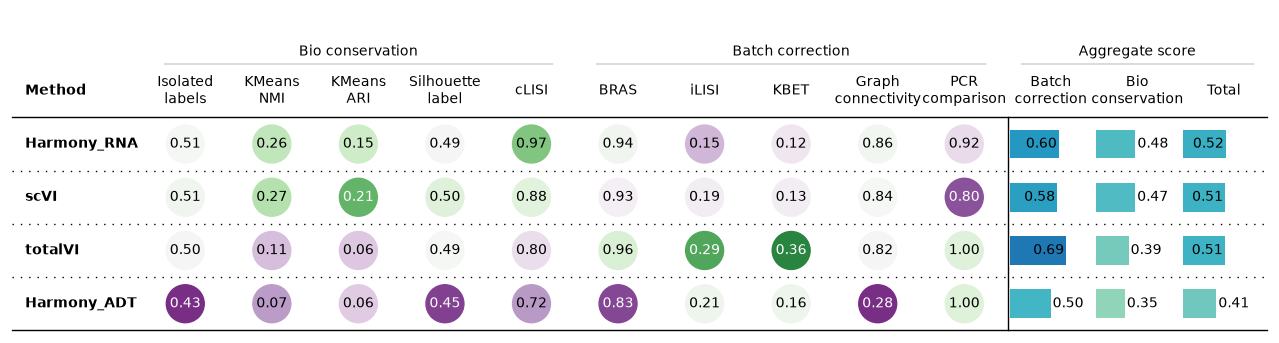

In [13]:
# 4. Run scib-metrics on the consolidated AnnData object
bm = Benchmarker(
    adata,
    batch_key="experiment",
    label_key="celltype_new",
    embedding_obsm_keys=["scVI", "totalVI", "Harmony_RNA", "Harmony_ADT"],
    n_jobs=-1
)

bm.benchmark()
results_df = bm.get_results()
print(results_df)

bm.plot_results_table(min_max_scale=False)

# For each embedding, it has to calculate 6 metrics


Embeddings: 100%|██████████| 4/4 [1:44:56<00:00, 1574.15s/it]


              Isolated labels        KMeans NMI        KMeans ARI  \
Embedding                                                           
scVI                 0.527332          0.267395          0.207105   
totalVI              0.525255          0.107319          0.060963   
Harmony_RNA          0.554164          0.256014           0.14838   
Harmony_ADT          0.403476          0.072214          0.064354   
Metric Type  Bio conservation  Bio conservation  Bio conservation   

             Silhouette label             cLISI              BRAS  \
Embedding                                                           
scVI                 0.503409          0.876355          0.922338   
totalVI              0.494716          0.799051          0.956929   
Harmony_RNA          0.493753           0.97412          0.936554   
Harmony_ADT          0.451864          0.716272          0.840246   
Metric Type  Bio conservation  Bio conservation  Batch correction   

                        iLISI   

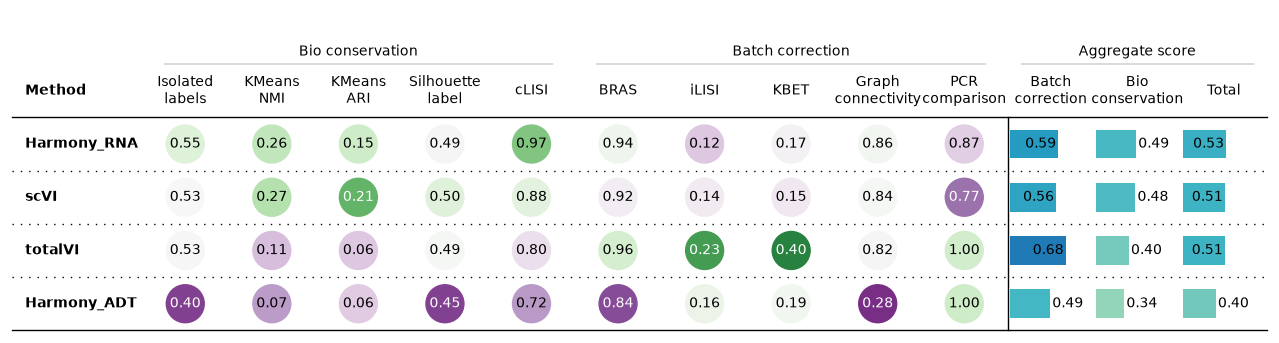

In [14]:
# 4. Run scib-metrics on the consolidated AnnData object
bm = Benchmarker(
    adata,
    batch_key="orig.ident",
    label_key="celltype_new",
    embedding_obsm_keys=["scVI", "totalVI", "Harmony_RNA", "Harmony_ADT"],
    n_jobs=-1
)

bm.benchmark()
results_df = bm.get_results()
print(results_df)
bm.plot_results_table(min_max_scale=False)
